In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os 
plt.style.use('plot_styles.mplstyle_new')

In [2]:
km_s = 1e5 #* cm/s
G = 6.67430e-8
Msun = 1.989e33
Lsun = 3.828e33
Rsun = 6.96e10

secinyear = 3.154e7
secinday = 86400

## check loading data

In [3]:
shell_data=np.loadtxt('../shell_propagation/shell_evolution_deltat_1yr.txt')
time = shell_data[:,0] #s
rsh = shell_data[:,1] #cm
vsh = shell_data[:,2] #cm/s
deltav_1 = shell_data[:,3] #cm/s
deltav_2 = shell_data[:,4] #cm/s
rhofl_1 = shell_data[:,5] #g/cm^3
rhofl_2 = shell_data[:,6] #g/cm^3
# int_rhofl_1_sq_dr = shell_data[:,7] #g^3/cm^5 #once it's added

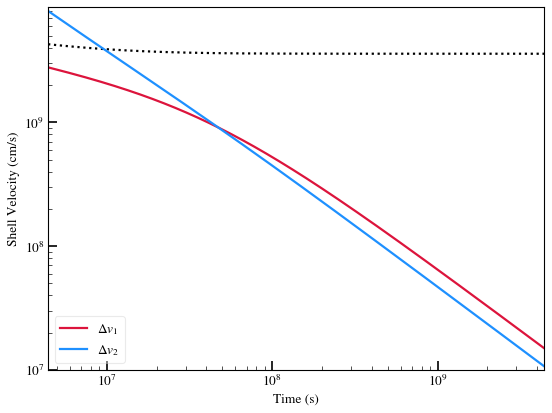

In [4]:
# plt.plot(time, rsh)
# plt.xlabel('Time (s)')
# plt.ylabel('Radius (cm)')

plt.plot(time, vsh,color='black',ls=':')
plt.plot(time, deltav_1,color='crimson',label=r'$\Delta v_{1}$')
plt.plot(time, deltav_2,color='dodgerblue',label=r'$\Delta v_{2}$')
plt.xlabel('Time (s)')
plt.ylabel('Shell Velocity (cm/s)')
plt.xscale('log')
plt.yscale('log')
plt.legend()

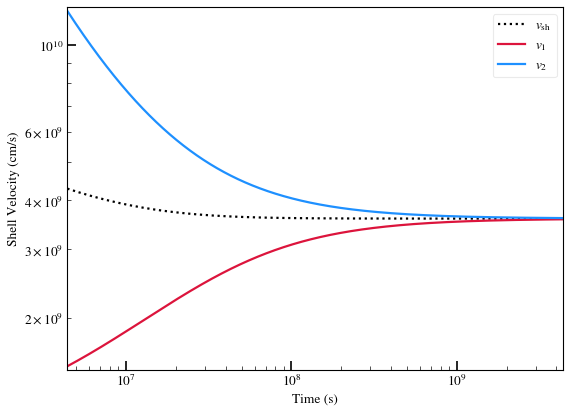

In [5]:
plt.plot(time, vsh,color='black',ls=':',label=r'$v_{\rm sh}$')
plt.plot(time, vsh-deltav_1,color='crimson',label=r'$v_{1}$')
plt.plot(time, deltav_2+vsh,color='dodgerblue',label=r'$v_{2}$')
plt.xlabel('Time (s)')
plt.ylabel('Shell Velocity (cm/s)')
plt.xscale('log')
plt.yscale('log')
plt.legend()

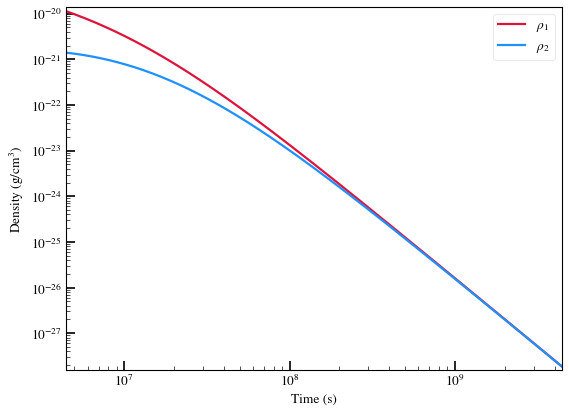

In [6]:
plt.plot(time,rhofl_1,color='crimson',label=r'$\rho_{1}$')
plt.plot(time,rhofl_2,color='dodgerblue',label=r'$\rho_{2}$')
plt.xlabel('Time (s)')
plt.ylabel('Density (g/cm$^3$)')
plt.xscale('log')
plt.yscale('log')
plt.legend()

In [7]:
'shell_evolution_deltat_1yr.txt'.split('.txt')

['shell_evolution_deltat_1yr', '']

## check loading shock_data.npz

In [8]:
shock_data = np.load('./evolve_spectrum_epsB_1e-2/shell_evolution_deltat_1yr/shock_data.npz')

In [9]:
shock_data.files

['times',
 'rsh_of_t',
 'vsh_of_t',
 'deltav1_of_t',
 'rho1_of_t',
 'deltav2_of_t',
 'rho2_of_t']

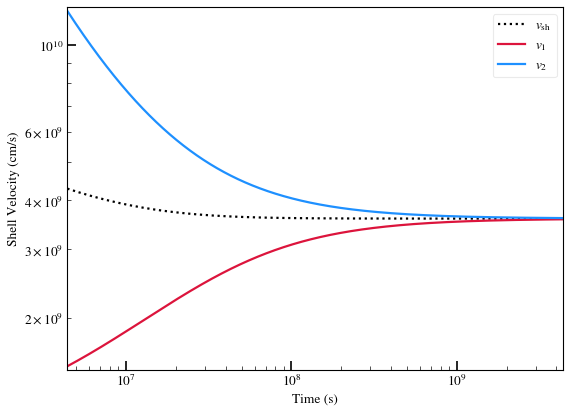

In [10]:
plt.plot(shock_data['times'], shock_data['vsh_of_t'],color='black',ls=':',label=r'$v_{\rm sh}$')
plt.plot(shock_data['times'], shock_data['vsh_of_t']-shock_data['deltav1_of_t'],color='crimson',label=r'$v_{1}$')
plt.plot(shock_data['times'], shock_data['deltav2_of_t']+shock_data['vsh_of_t'],color='dodgerblue',label=r'$v_{2}$')
plt.xlabel('Time (s)')
plt.ylabel('Shell Velocity (cm/s)')
plt.xscale('log')
plt.yscale('log')
plt.legend()

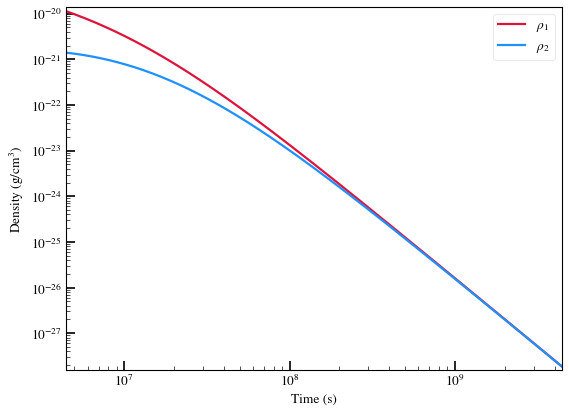

In [11]:
plt.plot(shock_data['times'], shock_data['rho1_of_t'],color='crimson',label=r'$\rho_{1}$')
plt.plot(shock_data['times'], shock_data['rho2_of_t'],color='dodgerblue',label=r'$\rho_{2}$')
plt.xlabel('Time (s)')
plt.ylabel('Density (g/cm$^3$)')
plt.xscale('log')
plt.yscale('log')
plt.legend()

In [12]:
shock_data['times']/secinyear

array([  0.14005557,   0.14045503,   0.14085513, ..., 139.46179455,
       139.60167089, 139.74168675])

In [13]:
p=3

def B(eps_B,rho,vel): #inputs in CGS
    return np.sqrt(8*np.pi*eps_B*rho*vel**2) #in Gauss
#assuming gamma_max -> infty, normalization of dn/dgamma = n0 * gamma^-p is:
def n0(eps_E,gamma_min,rho,vel,p=p): #this is number density for the energy distribution dn/dgamma
    return eps_E*((p-2)*gamma_min**(p-2))*rho*vel**2/(m_e.cgs.value*c.cgs.value**2)

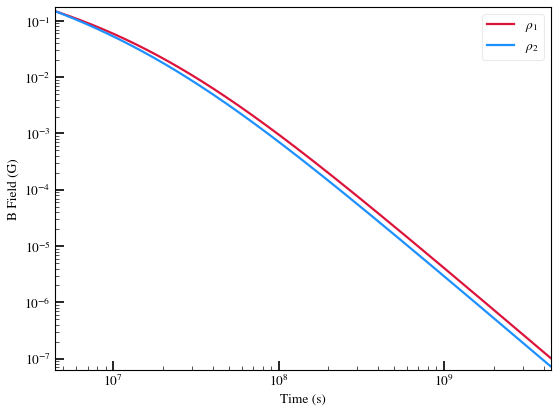

In [14]:
plt.plot(shock_data['times'],B(1e-2,shock_data['rho1_of_t'],shock_data['deltav1_of_t']),color='crimson',label=r'$\rho_{1}$')
plt.plot(shock_data['times'],B(1e-2,shock_data['rho2_of_t'],shock_data['deltav2_of_t']),color='dodgerblue',label=r'$\rho_{2}$')

plt.xlabel('Time (s)')
plt.ylabel('B Field (G)')
plt.xscale('log')
plt.yscale('log')
plt.legend()

# check loading spectrum data

In [15]:
flare1_dir = './evolve_spectrum_epsB_1e-2/shell_evolution_deltat_1yr/flare1/'
flare2_dir = './evolve_spectrum_epsB_1e-2/shell_evolution_deltat_1yr/flare2/'

In [19]:
os.listdir(flare1_dir), os.listdir(flare2_dir)

(['times.npy', 'dts.npy', 'yvals.npz', 'plots'],
 ['times.npy', 'dts.npy', 'yvals.npz', 'plots'])

flare 1
0
initial dynamical time, shock radius, shock velocity, normalization constant 1.260E+07 s, 5.398E+16 cm,4.285E+09 cm/s,1.090E+03 cm^-3
minimum time 0.35061294618186956 initial B field 0.14973921978260707 0.14973921978260707 max time 349.82717394640696
c1 -1.0 c2 -0.0003650704050798355 c3 8.16859897793764
normalization 1.7140788323204062e+53
minimum time 0.15041334939813567 maximum time 135.2599902236977 yr
max time times 139.74168674698794 max time tvals 135.2599902236977
flare 2
0
initial dynamical time, shock radius, shock velocity, normalization constant 1.260E+07 s, 5.398E+16 cm,4.285E+09 cm/s,1.090E+03 cm^-3
minimum time 0.35061294618186956 initial B field 0.14973921131475695 0.14973921131475695 max time 349.82717394640696
c1 -1.0 c2 -0.0003650703637898997 c3 23.34128448471055
normalization 1.7140786384558697e+53
minimum time 0.15041334939813567 maximum time 135.2599902236977 yr
max time times 139.74168674698794 max time tvals 135.2599902236977


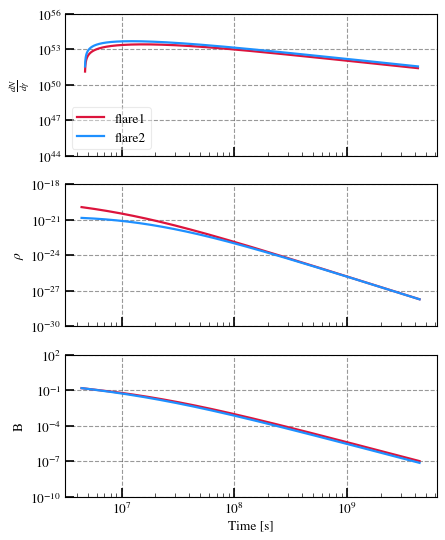

In [31]:
from astropy.constants import sigma_T,m_e,c
from scipy.interpolate import interp1d
# python spectrum_evolution.py 'evolve_spectrum/E_1.00E+51_Mej_1.00E+00_rhoprof_2.898M_Porb10/' \n
#'evolve_spectrum/evolve_spectrum_implicit/' --max_step=20000 --print_int=5000 --dt_sc=1e-3 --tf=1e6
km_s = 1e5 #* cm/s
G = 6.67430e-8
Msun = 1.989e33
Lsun = 3.828e33
Rsun = 6.96e10

secinyear = 3.154e7
secinday = 86400

eps_B=0.01
eps_E=0.01
p=3

def B(eps_B,rho,vel): #inputs in CGS
    return np.sqrt(8*np.pi*eps_B*rho*vel**2) #in Gauss
#assuming gamma_max -> infty, normalization of dn/dgamma = n0 * gamma^-p is:
def n0(eps_E,gamma_min,rho,vel): #this is number density for the energy distribution dn/dgamma
    return eps_E*gamma_min*rho*vel**2/(m_e.cgs.value*c.cgs.value**2)
#usually assume gamma_min=1
#adopt p=3 also
dndgamma_func = lambda gamma,n0_const,p: n0_const*gamma**(-p)

dict_colors=['crimson','dodgerblue']
dict_linestyles=['-','-']
# datadir_list = []
dNdgamma_dir_list = []
# for key in dict_4p08M_paths.keys():
data_dir='./evolve_spectrum_epsB_1e-2/shell_evolution_deltat_1yr/'
dNdgamma_dir_list.append(flare1_dir)
# datadir_list.append('./evolve_spectrum_epsB_1e-2/')
dNdgamma_dir_list.append(flare2_dir)

shock_data = np.load(data_dir + 'shock_data.npz')
times_orig = shock_data['times']
vsh_orig = shock_data['vsh_of_t']
rsh_of_t = shock_data['rsh_of_t']
rho1_of_t = shock_data['rho1_of_t']
rho2_of_t = shock_data['rho2_of_t']
deltav1_of_t = shock_data['deltav1_of_t']
deltav2_of_t = shock_data['deltav2_of_t']

fig, ax = plt.subplots(3,1,figsize=(6,8),sharex=True)
for flare,dNdgamma_dir in enumerate(dNdgamma_dir_list):
    if flare==0:
        rho_of_t = rho1_of_t
        vsh_of_t = deltav1_of_t
    elif flare==1:
        rho_of_t = rho2_of_t
        vsh_of_t = deltav2_of_t
    print('flare',flare+1)
    # if key != 'fomega0p3':
    #     continue
    B_of_t = B(eps_B=eps_B,rho=rho_of_t,vel=vsh_of_t)
    times = times_orig
    ind_start=0
    print(ind_start)
    vsh_of_t = vsh_of_t[ind_start:]
    rsh_of_t = rsh_of_t[ind_start:]
    rho_of_t = rho_of_t[ind_start:]

    n0_of_t = n0(eps_E=eps_E,gamma_min=1,rho=rho_of_t,vel=vsh_of_t)
    # B_of_t = B(eps_B=1e-2,rho=rho_of_t,vel=vsh_of_t)

    #nondimensionalize to initial values of vsh, rsh, and initial dynamical time t_dyn ~ rsh/vsh
    adjust_const = 1 #1e-12
    vsh_t0 = vsh_orig[0]
    rsh_t0 = rsh_of_t[0]
    tdyn_t0 = rsh_t0/vsh_t0
    #also scale N by initial value N_t0 = n0_t0 * rsh_t0**3
    n0_t0 = n0_of_t[0]
    N_t0 = n0_t0 * rsh_t0**3

    vsh_tot_func_ND = interp1d(times/tdyn_t0,vsh_orig/vsh_t0,kind='linear')
    vsh_func_ND = interp1d(times/tdyn_t0,vsh_of_t/vsh_t0,kind='linear')
    rsh_func_ND = interp1d(times/tdyn_t0,rsh_of_t/rsh_t0,kind='linear')
    n0_func_ND = interp1d(times/tdyn_t0,n0_of_t/n0_t0,kind='linear')

    B_func = interp1d(times/tdyn_t0,B_of_t,kind='linear')
    coeff_rad_ND = lambda t: -((sigma_T.cgs.value * B_func(t)**2)/(6 * np.pi * m_e.cgs.value * c.cgs.value))*tdyn_t0

    print("initial dynamical time, shock radius, shock velocity, normalization constant", 
        f'{tdyn_t0:1.3E} s, {rsh_t0:1.3E} cm,{vsh_t0:1.3E} cm/s,{n0_t0:1.3E} cm^-3')
    print('minimum time', times[0]/tdyn_t0,'initial B field',B_func(times[0]/tdyn_t0),B_of_t[0],'max time',times[-1]/tdyn_t0)

    #time dependent coefficients for heating and cooling terms
    c1 = lambda t: -vsh_tot_func_ND(t)/rsh_func_ND(t)/adjust_const
    c2 = lambda t: coeff_rad_ND(t)/adjust_const
    c3 = lambda t: 4 * np.pi * rsh_func_ND(t)**2 * vsh_func_ND(t) * n0_func_ND(t)/adjust_const

    print('c1',c1(times[0]/tdyn_t0),'c2',c2(times[0]/tdyn_t0), 'c3',c3(times[0]/tdyn_t0) )

    # delta_gamma = 100
    delta_gamma = 1e-3 # not using even spacing
    gamma_max = 1e8 #actually calculate this
    gamma_min = 1
    N_g = 256
    d_ln_gamma = (np.log(gamma_max) - np.log(gamma_min))/N_g
    # gamma_e_vals = np.arange(gamma_min,gamma_max,delta_gamma)
    gamma_e_vals = np.zeros(N_g)
    gamma_e_vals[0] = gamma_min
    for i in np.arange(1,N_g):
        gamma_e_vals[i] = gamma_e_vals[i-1] + (np.exp(d_ln_gamma)-1)*gamma_e_vals[i-1]
    delta_gamma_e = gamma_e_vals*(np.exp(d_ln_gamma)-1)

    dt_scale_sim = 1e-3

    dts = np.load(dNdgamma_dir+'dts.npy')
    tvals=np.load(dNdgamma_dir+'times.npy')
    yvals=np.load(dNdgamma_dir+'yvals.npz')['arr_0'].reshape((len(tvals),len(gamma_e_vals)))
    #convert yvals to the right units
    dNdgamma_vals = yvals * n0_t0 * rsh_t0**3
    print('normalization',n0_t0 * rsh_t0**3)
    tdyn_of_t_sim = dts/dt_scale_sim

    tvals_sec = tvals*tdyn_t0
    print('minimum time', tvals_sec[0]/secinyear,'maximum time', tvals_sec[-1]/secinyear, 'yr')
    print('max time times',times[-1]/secinyear,'max time tvals',tvals[-1]*tdyn_t0/secinyear)
    # print(dNdgamma_vals[:,0].shape,tvals.shape)
    ax[0].plot(tvals_sec,dNdgamma_vals[:,0],color=dict_colors[flare],ls=dict_linestyles[flare],label='flare'+str(flare+1))

    ax[1].plot(times,rho_of_t,color=dict_colors[flare],ls=dict_linestyles[flare])
    ax[2].plot(times,B_of_t,color=dict_colors[flare],ls=dict_linestyles[flare])
ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[2].set_yscale('log')
ax[2].set_xscale('log')
# ax[2].set_xlim(1e-5,)
ax[0].set_ylabel(r'$\frac{dN}{d\gamma}$')
ax[1].set_ylabel(r'$\rho$')
ax[2].set_ylabel(r'B')
ax[2].set_xlabel('Time [s]')
ax[0].grid()
ax[1].grid()
ax[2].grid()
ax[0].set_ylim(1e44,1e56)
ax[1].set_ylim(1e-30,1e-18)
ax[2].set_ylim(1e-10,1e2)
ax[2].set_xlim(1e-1*secinyear,200*secinyear)
ax[0].legend()

In [22]:
os.listdir('./evolve_spectrum_epsB_1e-2')

['shell_evolution_deltat_1yr']